In [6]:
# Correlation analysis: Hyanglin_dataset_merged_daytime_5_19.xlsx
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COL = "output_power"
DATA_PATH = os.path.join("..", "2. PV_Power_Data", "Hyanglin_dataset_merged_daytime_5_19.xlsx")

df = pd.read_excel(DATA_PATH)
numeric = df.select_dtypes(include=[np.number])
if TARGET_COL not in numeric.columns:
    numeric = numeric.join(df[[TARGET_COL]])
feature_cols = [c for c in numeric.columns if c != TARGET_COL]
corr_with_target = numeric.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL, errors="ignore").abs().sort_values(ascending=False)
corr_matrix = numeric[feature_cols + [TARGET_COL]].corr()

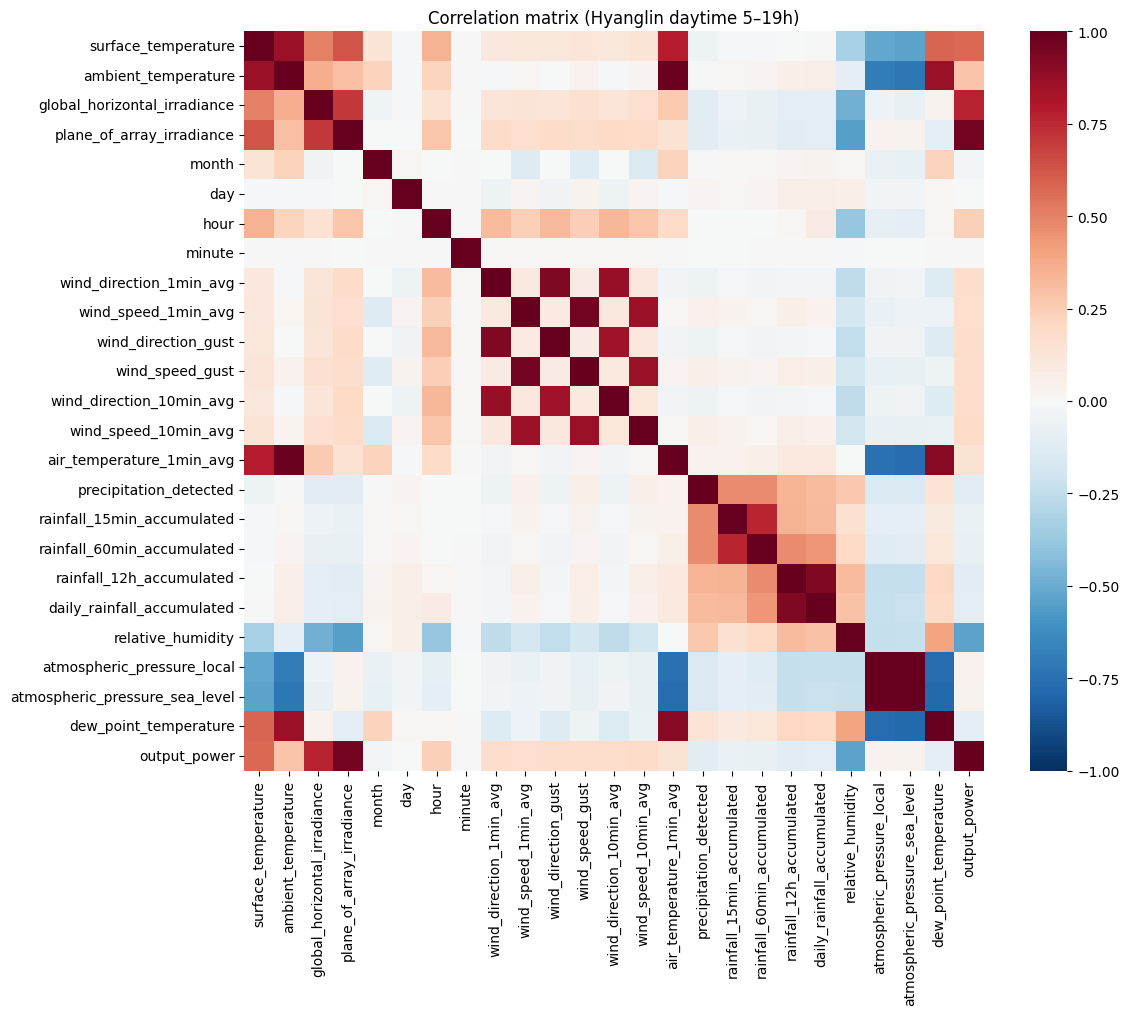

In [7]:
# Correlation heatmap (features + target)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix (Hyanglin daytime 5–19h)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Feature-target correlation bins (|r|): count and list features per bin
labels = ["<=0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", ">=0.3"]
r = corr_with_target

def bin_features(ser):
    out = {}
    out["<=0.05"] = ser[ser <= 0.05].sort_values().index.tolist()
    out["0.05-0.1"] = ser[(ser > 0.05) & (ser <= 0.1)].sort_values().index.tolist()
    out["0.1-0.2"] = ser[(ser > 0.1) & (ser <= 0.2)].sort_values().index.tolist()
    out["0.2-0.3"] = ser[(ser > 0.2) & (ser <= 0.3)].sort_values().index.tolist()
    out[">=0.3"] = ser[ser > 0.3].sort_values(ascending=False).index.tolist()
    return out

binned = bin_features(r)
print("Feature-target |correlation| by bin:")
print("=" * 60)
for lb in labels:
    names = binned[lb]
    print(f"\n  {lb}: {len(names)} features")
    for name in names:
        print(f"      {name}   r = {r[name]:+.3f}")
print("\n" + "-" * 60)
print(f"  Total: {len(corr_with_target)} features")

Feature-target |correlation| by bin:

  <=0.05: 5 features
      minute   r = +0.000
      day   r = +0.004
      month   r = +0.029
      atmospheric_pressure_sea_level   r = +0.037
      atmospheric_pressure_local   r = +0.047

  0.05-0.1: 3 features
      rainfall_15min_accumulated   r = +0.066
      rainfall_60min_accumulated   r = +0.078
      dew_point_temperature   r = +0.098

  0.1-0.2: 10 features
      daily_rainfall_accumulated   r = +0.105
      rainfall_12h_accumulated   r = +0.113
      precipitation_detected   r = +0.117
      air_temperature_1min_avg   r = +0.142
      wind_speed_1min_avg   r = +0.167
      wind_direction_1min_avg   r = +0.176
      wind_direction_gust   r = +0.178
      wind_direction_10min_avg   r = +0.180
      wind_speed_gust   r = +0.183
      wind_speed_10min_avg   r = +0.194

  0.2-0.3: 2 features
      hour   r = +0.236
      ambient_temperature   r = +0.284

  >=0.3: 4 features
      plane_of_array_irradiance   r = +0.968
      global_horizonta

In [9]:
# Feature-feature correlation: count and list pairs above thresholds
ff_corr = numeric[feature_cols].corr()
n = len(feature_cols)

# Collect all pairs (i, j) with i < j and their correlation
pairs_list = []
for i in range(n):
    for j in range(i + 1, n):
        r = ff_corr.iloc[i, j]
        pairs_list.append((feature_cols[i], feature_cols[j], r))

thresholds = [0.9, 0.8, 0.7, 0.6, 0.5]
print("Feature-feature |correlation| (upper triangle):")
print("=" * 60)
for t in thresholds:
    above = [(a, b, r) for a, b, r in pairs_list if abs(r) >= t]
    print(f"\n  >= {t:.1f}: {len(above)} pairs")
    for a, b, r in sorted(above, key=lambda x: -abs(x[2])):
        print(f"      {a}  <->  {b}   r = {r:+.3f}")
print("\n" + "-" * 60)
print(f"  Total pairs: {len(pairs_list)}")

Feature-feature |correlation| (upper triangle):

  >= 0.9: 6 pairs
      atmospheric_pressure_local  <->  atmospheric_pressure_sea_level   r = +0.999
      ambient_temperature  <->  air_temperature_1min_avg   r = +0.985
      wind_speed_1min_avg  <->  wind_speed_gust   r = +0.963
      rainfall_12h_accumulated  <->  daily_rainfall_accumulated   r = +0.937
      wind_direction_1min_avg  <->  wind_direction_gust   r = +0.932
      air_temperature_1min_avg  <->  dew_point_temperature   r = +0.912

  >= 0.8: 12 pairs
      atmospheric_pressure_local  <->  atmospheric_pressure_sea_level   r = +0.999
      ambient_temperature  <->  air_temperature_1min_avg   r = +0.985
      wind_speed_1min_avg  <->  wind_speed_gust   r = +0.963
      rainfall_12h_accumulated  <->  daily_rainfall_accumulated   r = +0.937
      wind_direction_1min_avg  <->  wind_direction_gust   r = +0.932
      air_temperature_1min_avg  <->  dew_point_temperature   r = +0.912
      wind_direction_1min_avg  <->  wind_directio